# skforecast-ai — MVP Demo

This notebook demonstrates the complete **MVP** of skforecast-ai (Phases 1–9).

The package provides an AI-powered forecasting assistant that:
1. **Profiles** your time series data
2. **Recommends** a forecasting strategy (deterministically)
3. **Generates** a complete Python script
4. **Executes** the forecasting workflow and returns real predictions + metrics

All of this works in **Tier 0** (no LLM required). When an LLM is configured,
the assistant can also explain plans in natural language and answer free-form
forecasting questions.

---

## Architecture Overview

```
ForecastingAssistant
├── inspect()        → DataProfile
├── recommend()      → RecommendResult (profile + plan)
├── generate_code()  → GenerateResult (profile + plan + code)
├── run()            → RunResult (profile + plan + code + predictions + metrics)
├── ask()            → AskResult (requires LLM)
└── explain()        → str (requires LLM)
```

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import skforecast_ai
from skforecast_ai import ForecastingAssistant, RunResult

print(f"skforecast-ai version: {skforecast_ai.__version__}")

skforecast-ai version: 0.1.0


## 2. Sample Data

We create a daily sales dataset with trend, seasonality, and an exogenous
variable (temperature).

In [2]:
rng = np.random.default_rng(42)
n = 365
dates = pd.date_range("2023-01-01", periods=n, freq="D")

trend = np.linspace(100, 150, n)
seasonality = 10 * np.sin(2 * np.pi * np.arange(n) / 7)
noise = rng.normal(0, 3, n)

df = pd.DataFrame({
    "date": dates,
    "sales": trend + seasonality + noise,
    "temperature": 15 + 10 * np.sin(2 * np.pi * np.arange(n) / 365),
})

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.head(10)

Shape: (365, 3)
Date range: 2023-01-01 00:00:00 → 2023-12-31 00:00:00


,date,sales,temperature
0,2023-01-01,100.914151,15.000000
1,2023-01-02,104.835725,15.172134
2,2023-01-03,112.275358,15.344216
3,2023-01-04,107.572619,15.516197
4,2023-01-05,90.357508,15.688024
5,2023-01-06,87.030996,15.859648
6,2023-01-07,93.389382,16.031017
7,2023-01-08,100.012811,16.202080
8,2023-01-09,108.866812,16.372788
9,2023-01-10,108.426411,16.543088


## 3. Create the Assistant (Tier 0 — No LLM)

The assistant works fully deterministically without any LLM configuration.

In [3]:
assistant = ForecastingAssistant()

print(f"LLM configured: {assistant.llm}")
print(f"Mode: Tier 0 (deterministic)")

LLM configured: None
Mode: Tier 0 (deterministic)


## 4. Inspect — Profile the Dataset

The `inspect()` method analyzes the dataset structure: detects frequency,
identifies exogenous variables, checks for missing values, and infers
seasonal patterns.

In [4]:
profile = assistant.inspect(data=df, target="sales", date_column="date")

print(f"Observations:    {profile.n_observations}")
print(f"Series:          {profile.n_series}")
print(f"Frequency:       {profile.frequency}")
print(f"Index type:      {profile.index_type}")
print(f"Exog columns:    {profile.exog_columns}")
print(f"Seasonalities:   {profile.inferred_seasonalities}")
print(f"Missing values:  {profile.missing_values}")
print(f"Warnings:        {profile.warnings}")

Observations:    365
Series:          1
Frequency:       D
Index type:      datetime
Exog columns:    ['temperature']
Seasonalities:   [7, 365]
Missing values:  {}
Warnings:        []


## 5. Recommend — Generate a Forecasting Plan

The `recommend()` method profiles the data and produces a complete
forecasting strategy using deterministic rules (no LLM involved).

In [ ]:
result = assistant.recommend(
    data         = df,
    target       = "sales",
    date_column  = "date",
    steps      = 30,
)

plan = result.plan
print("=== Forecast Plan ===")
print(f"Task type:           {plan.task_type}")
print(f"Forecaster:          {plan.forecaster}")
print(f"Estimator:           {plan.estimator}")
print(f"steps:             {plan.steps} steps")
print(f"Lags:                {plan.lags}")
print(f"Metric:              {plan.metric}")
print(f"Backtesting:         {plan.backtesting_strategy}")
print(f"Intervals:           {plan.interval_method}")
print(f"dropna_from_series:  {plan.dropna_from_series}")
print(f"Use exog:            {plan.use_exog}")
print(f"\nRationale: {plan.rationale}")

=== Forecast Plan ===
Task type:           single_series
Forecaster:          ForecasterRecursive
Estimator:           Ridge
Horizon:             30 steps
Lags:                [1, 2, 3, 4, 5, 6, 7]
Metric:              mean_absolute_error
Backtesting:         TimeSeriesFold
Intervals:           bootstrapping
dropna_from_series:  False
Use exog:            True

Rationale: A single-series ML forecaster (ForecasterRecursive) is recommended. The estimator is Ridge. Lags: [1, 2, 3, 4, 5, 6, 7]. Metric: mean_absolute_error. Prediction intervals via bootstrapping. Exogenous variables detected: ['temperature'].


## 6. Generate Code — Produce a Complete Script

The `generate_code()` method produces a self-contained, runnable Python
script that implements the recommended forecasting workflow.

In [ ]:
result = assistant.generate_code(
    data         = df,
    target       = "sales",
    date_column  = "date",
    steps      = 30,
    data_path    = "sales_data.csv",
)

print(f"Code length: {len(result.code)} characters")
print(f"{'=' * 60}")
print(result.code)

Code length: 1521 characters
import pandas as pd
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from sklearn.linear_model import Ridge

# Load data
data = pd.read_csv('sales_data.csv', index_col=0, parse_dates=True)
data = data.asfreq('D')

# Train/test split (time-based)
n_train = int(len(data) * 0.8)
y_train = data.iloc[:n_train]['sales']
y_test = data.iloc[n_train:]['sales']
exog_train = data.iloc[:n_train][['temperature']]
exog_test = data.iloc[n_train:][['temperature']]

# Create forecaster
forecaster = ForecasterRecursive(
    estimator = Ridge(random_state=123),
    lags      = [1, 2, 3, 4, 5, 6, 7],
    dropna_from_series = False,
)

# Fit
forecaster.fit(y=y_train, exog=exog_train)

# Predict
predictions = forecaster.predict(steps=30, exog=exog_test.iloc[:30])
print(predictions)

# Backtesting
cv = TimeSeriesFold(
    steps              = 30,
    initial_train_size = n_train,
    refit          

## 7. Run — Execute the Full Pipeline (Phase 9)

The `run()` method is the **key MVP feature**. It executes the entire
forecasting workflow end-to-end:

1. Profiles the data
2. Recommends a plan
3. Generates the equivalent code
4. **Executes** the workflow programmatically (no `exec()`!)
5. Returns actual predictions, backtesting metrics, and optional intervals

All execution is done by calling skforecast functions directly — safe,
testable, and reproducible.

In [ ]:
run_result = assistant.forecast(
    data         = df,
    target       = "sales",
    date_column  = "date",
    steps      = 30,
)

print(f"Type: {type(run_result).__name__}")
assert isinstance(run_result, RunResult)

100%|██████████| 3/3 [00:00<00:00, 1173.23it/s]

Type: RunResult


### 7.1 Backtesting Metric

In [8]:
print(f"Metric: {run_result.metric_name}")
print(f"Value:  {run_result.metric_value:.4f}")
print(f"\nThis is the backtesting MAE computed via TimeSeriesFold on the")
print(f"test set (last 20% of the data).")

Metric: mean_absolute_error
Value:  3.4559

This is the backtesting MAE computed via TimeSeriesFold on the
test set (last 20% of the data).


### 7.2 Predictions

In [ ]:
print(f"Predictions shape: {run_result.predictions.shape}")
print(f"steps requested: {run_result.plan.steps}")
print()
run_result.predictions

Predictions shape: (30, 1)
Horizon requested: 30



,pred
2023-12-02,136.943118
2023-12-03,145.831458
2023-12-04,155.270364
2023-12-05,156.313778
2023-12-06,148.866842
2023-12-07,139.489650
2023-12-08,135.598635
2023-12-09,138.106270
2023-12-10,146.598705
2023-12-11,154.510862


### 7.3 Prediction Intervals

In [10]:
if run_result.intervals is not None:
    print(f"Intervals shape: {run_result.intervals.shape}")
    print()
    display(run_result.intervals.head(10))
else:
    print("No prediction intervals (series may be too short or interval_method=None).")
    print(f"Plan interval_method: {run_result.plan.interval_method}")

Intervals shape: (30, 3)



,pred,lower_bound,upper_bound
2023-12-02,136.943118,130.914007,139.840515
2023-12-03,145.831458,140.063488,150.491215
2023-12-04,155.270364,150.293850,159.958707
2023-12-05,156.313778,151.431122,161.461799
2023-12-06,148.866842,143.964649,154.137160
2023-12-07,139.489650,134.845548,144.669625
2023-12-08,135.598635,129.480618,139.293796
2023-12-09,138.106270,130.665117,143.691770
2023-12-10,146.598705,139.636881,151.643999
2023-12-11,154.510862,148.340640,160.738919


### 7.4 Warnings

In [11]:
if run_result.warnings:
    for w in run_result.warnings:
        print(f"  ⚠ {w}")
else:
    print("No warnings — all validations passed.")

No warnings — all validations passed.


### 7.5 Generated Code (included in RunResult)

In [12]:
print(f"The RunResult also includes the equivalent code ({len(run_result.code)} chars):")
print(run_result.code[:500] + "\n...")

The RunResult also includes the equivalent code (1515 chars):
import pandas as pd
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from sklearn.linear_model import Ridge

# Load data
data = pd.read_csv('data.csv', index_col=0, parse_dates=True)
data = data.asfreq('D')

# Train/test split (time-based)
n_train = int(len(data) * 0.8)
y_train = data.iloc[:n_train]['sales']
y_test = data.iloc[n_train:]['sales']
exog_train = data.iloc[:n_train][['temperature']]
exog_test = data.ilo
...


## 8. Visualize Predictions

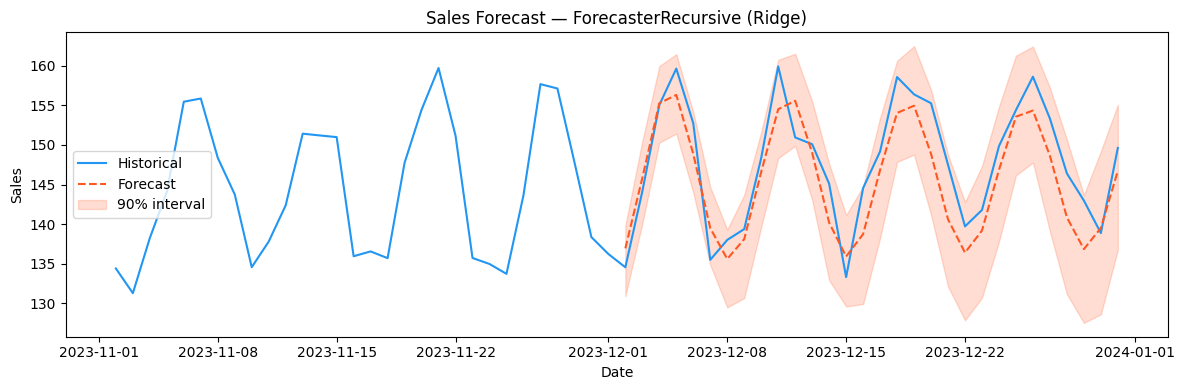

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

# Historical data (last 60 days)
df_plot = df.set_index("date")
ax.plot(df_plot.index[-60:], df_plot["sales"].iloc[-60:], label="Historical", color="#2196F3")

# Predictions
ax.plot(run_result.predictions.index, run_result.predictions.iloc[:, 0],
        label="Forecast", color="#FF5722", linestyle="--")

# Intervals
if run_result.intervals is not None and len(run_result.intervals.columns) >= 3:
    ax.fill_between(
        run_result.intervals.index,
        run_result.intervals.iloc[:, 1],
        run_result.intervals.iloc[:, 2],
        alpha=0.2, color="#FF5722", label="90% interval",
    )

ax.set_title(f"Sales Forecast — {run_result.plan.forecaster} ({run_result.plan.estimator})")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Run with Intervals (Bootstrapping)

By providing a longer series, the recommendation engine will enable
prediction intervals automatically.

In [ ]:
# Create a longer series (500 observations) to trigger interval recommendation
rng2 = np.random.default_rng(123)
n2 = 500
dates2 = pd.date_range("2022-01-01", periods=n2, freq="D")

df_long = pd.DataFrame({
    "date": dates2,
    "sales": np.linspace(80, 200, n2) + 8 * np.sin(2 * np.pi * np.arange(n2) / 7) + rng2.normal(0, 4, n2),
})

run_long = assistant.run(
    data         = df_long,
    target       = "sales",
    date_column  = "date",
    steps      = 14,
)

print(f"Metric ({run_long.metric_name}): {run_long.metric_value:.4f}")
print(f"Interval method: {run_long.plan.interval_method}")
print(f"Intervals available: {run_long.intervals is not None}")

if run_long.intervals is not None:
    print(f"\nInterval predictions:")
    display(run_long.intervals)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 393, number of used features: 7
[LightGBM] [Info] Start training from score 128.955669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

100%|██████████| 8/8 [00:00<00:00, 1257.85it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1155
[LightGBM] [Info] Number of data points in the train set: 493, number of used features: 7
[LightGBM] [Info] Start training from score 140.884245
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,pred,lower_bound,upper_bound
2023-05-16,199.606505,195.668457,204.801005
2023-05-17,195.345028,191.252302,200.539528
2023-05-18,193.748045,187.153727,198.061496
2023-05-19,197.549317,193.399380,203.379713
2023-05-20,201.973445,195.417889,204.013366
2023-05-21,199.942904,195.970308,205.378441
2023-05-22,199.606505,195.393160,204.560342
2023-05-23,199.510615,194.354481,203.173149
2023-05-24,196.601150,190.778120,201.518377
2023-05-25,199.510615,190.792857,203.824066


## 10. Multi-Series Example

The assistant also handles multi-series data in long format.

In [15]:
# Create multi-series data (3 stores)
rng3 = np.random.default_rng(99)
n3 = 200
dates3 = pd.date_range("2023-01-01", periods=n3, freq="D")

df_multi = pd.concat([
    pd.DataFrame({
        "date": dates3,
        "store": store,
        "revenue": base + np.cumsum(rng3.normal(0.5, 2, n3)),
    })
    for store, base in [("NYC", 100), ("LA", 150), ("CHI", 80)]
], ignore_index=True)

print(f"Multi-series shape: {df_multi.shape}")
print(f"Stores: {df_multi['store'].unique().tolist()}")
df_multi.head()

Multi-series shape: (600, 3)
Stores: ['NYC', 'LA', 'CHI']


,date,store,revenue
0,2023-01-01,NYC,100.664989
1,2023-01-02,NYC,100.236152
2,2023-01-03,NYC,100.837182
3,2023-01-04,NYC,102.709644
4,2023-01-05,NYC,99.696063


In [ ]:
run_multi = assistant.run(
    data              = df_multi,
    target            = "revenue",
    date_column       = "date",
    series_id_column  = "store",
    steps           = 7,
)

print(f"Plan: {run_multi.plan.forecaster}")
print(f"Metric ({run_multi.metric_name}): {run_multi.metric_value:.4f}")
print(f"\nPredictions (7 steps × 3 series = {len(run_multi.predictions)} rows):")
run_multi.predictions

ValueError: `series` has a pandas DatetimeIndex without a frequency. To avoid this error, set the frequency of the DatetimeIndex.

## 11. Missing Values & `dropna_from_series`

The recommendation engine automatically decides whether to set
`dropna_from_series=True` or `False` based on the estimator and data quality.

- **NaN-tolerant estimators** (LGBMRegressor, CatBoost, XGBoost) → `False`
- **Non-tolerant estimators** (Ridge, RandomForest) with missing data → `True`
- **Statistical / Foundation models** → `None` (not applicable)

In [ ]:
# Create a dataset with missing values (short series → Ridge estimator)
rng4 = np.random.default_rng(77)
n4 = 200
dates4 = pd.date_range("2023-01-01", periods=n4, freq="D")
sales4 = np.linspace(50, 100, n4) + rng4.normal(0, 3, n4)

# Inject missing values
sales4[10] = np.nan
sales4[50] = np.nan
sales4[120] = np.nan

df_missing = pd.DataFrame({"date": dates4, "sales": sales4})

result_missing = assistant.recommend(
    data=df_missing, target="sales", date_column="date", steps=10
)
plan_missing = result_missing.plan

print(f"Estimator:           {plan_missing.estimator}")
print(f"dropna_from_series:  {plan_missing.dropna_from_series}")
print(f"Data requirements:   {plan_missing.data_requirements}")
print(f"\n→ Ridge cannot handle NaN, so dropna_from_series=True is recommended.")

In [ ]:
# With a larger dataset, LGBMRegressor is selected → dropna_from_series=False
rng5 = np.random.default_rng(88)
n5 = 600
dates5 = pd.date_range("2022-01-01", periods=n5, freq="D")
sales5 = np.linspace(50, 200, n5) + rng5.normal(0, 5, n5)
sales5[30] = np.nan
sales5[200] = np.nan

df_missing_large = pd.DataFrame({"date": dates5, "sales": sales5})

result_lgbm = assistant.recommend(
    data=df_missing_large, target="sales", date_column="date", steps=14
)
plan_lgbm = result_lgbm.plan

print(f"Estimator:           {plan_lgbm.estimator}")
print(f"dropna_from_series:  {plan_lgbm.dropna_from_series}")
print(f"\n→ LGBMRegressor handles NaN natively, so dropna_from_series=False.")

## 12. LLM Fallback — Graceful Degradation

When an LLM is configured but unavailable (network error, wrong API key, etc.),
the assistant **does not crash**. It falls back to deterministic mode and returns
a useful result with a warning.

In [ ]:
import warnings as _warnings

# Configure with a non-existent LLM provider
assistant_with_llm = ForecastingAssistant(llm="openai:fake-nonexistent-model")

# ask() will attempt the LLM, fail, and fall back to deterministic mode
with _warnings.catch_warnings(record=True) as caught:
    _warnings.simplefilter("always")
    ask_result = assistant_with_llm.ask(
        question="What forecaster should I use for daily sales?",
        data=df,
    )

print("=== LLM Fallback Result ===")
print(f"Crashed: No!")
print(f"Plan returned: {ask_result.plan is not None}")
print(f"Explanation: {ask_result.explanation[:80]}...")
print(f"\nWarning emitted: {caught[0].message}" if caught else "\nNo warning")

In [ ]:
# explain() also falls back gracefully
with _warnings.catch_warnings(record=True) as caught:
    _warnings.simplefilter("always")
    explanation = assistant_with_llm.explain(plan=plan)

print("=== explain() Fallback ===")
print(f"Result: {explanation}")
print(f"\n→ Falls back to plan.rationale instead of crashing.")

## 13. RunResult Summary

The `RunResult` object contains everything the user needs:

In [ ]:
print("RunResult fields:")
print(f"  .profile       → DataProfile (n_obs={run_result.profile.n_observations}, freq={run_result.profile.frequency})")
print(f"  .plan          → ForecastPlan (forecaster={run_result.plan.forecaster})")
print(f"  .code          → str ({len(run_result.code)} chars)")
print(f"  .metric_name   → '{run_result.metric_name}'")
print(f"  .metric_value  → {run_result.metric_value:.4f}")
print(f"  .predictions   → DataFrame {run_result.predictions.shape}")
print(f"  .intervals     → {type(run_result.intervals).__name__ if run_result.intervals is not None else 'None'}")
print(f"  .warnings      → {run_result.warnings}")

## 14. One-Liner: From Data to Forecast

The entire workflow in a single call:

In [ ]:
result = ForecastingAssistant().run(data=df, target="sales", date_column="date", steps=14)

print(f"Forecast {result.plan.steps} days ahead using {result.plan.forecaster}")
print(f"Backtesting MAE: {result.metric_value:.4f}")
print(f"\nPredictions:")
result.predictions

---

## Summary

| Method | Input | Output | LLM Required |
|--------|-------|--------|-------------|
| `inspect()` | DataFrame/CSV | `DataProfile` | No |
| `recommend()` | DataFrame/CSV + horizon | `RecommendResult` | No |
| `generate_code()` | DataFrame/CSV + horizon | `GenerateResult` | No |
| **`run()`** | **DataFrame/CSV + horizon** | **`RunResult`** | **No** |
| `ask()` | question + optional data | `AskResult` | Yes (fallback to Tier 0 on failure) |
| `explain()` | ForecastPlan | str | Yes (fallback to `plan.rationale` on failure) |

The MVP is fully functional without any LLM. Adding an LLM (`llm="ollama:qwen2.5:7b-instruct"`)
enables natural language explanations and free-form Q&A on top of the deterministic core.
If the LLM is unreachable, `ask()` and `explain()` degrade gracefully instead of crashing.

## CLI Commands

All functionality is also available via the command line:

```bash
skforecast-ai inspect data.csv --target sales --date date
skforecast-ai recommend data.csv --target sales --date date --horizon 30
skforecast-ai generate-code data.csv --target sales --date date --horizon 30
skforecast-ai run data.csv --target sales --date date --horizon 30 --json
skforecast-ai explain data.csv --target sales --date date --horizon 30
skforecast-ai explain data.csv --target sales --horizon 30 --llm "openai:gpt-4o-mini"
```